# 2.3 Feature Engineering

## Importar paquetes

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

sns.set_theme(style='whitegrid')

## Carga de datos

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Codificación de variables categóricas

In [3]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
31,1,1,0,29.699118,1,0,146.5208,0
773,0,3,1,29.699118,0,0,7.2250,0
201,0,3,1,29.699118,8,2,69.5500,2
613,0,3,1,29.699118,0,0,7.7500,1
116,0,3,1,70.500000,0,0,7.7500,1


## Distribución de Age y Fare antes de transformar

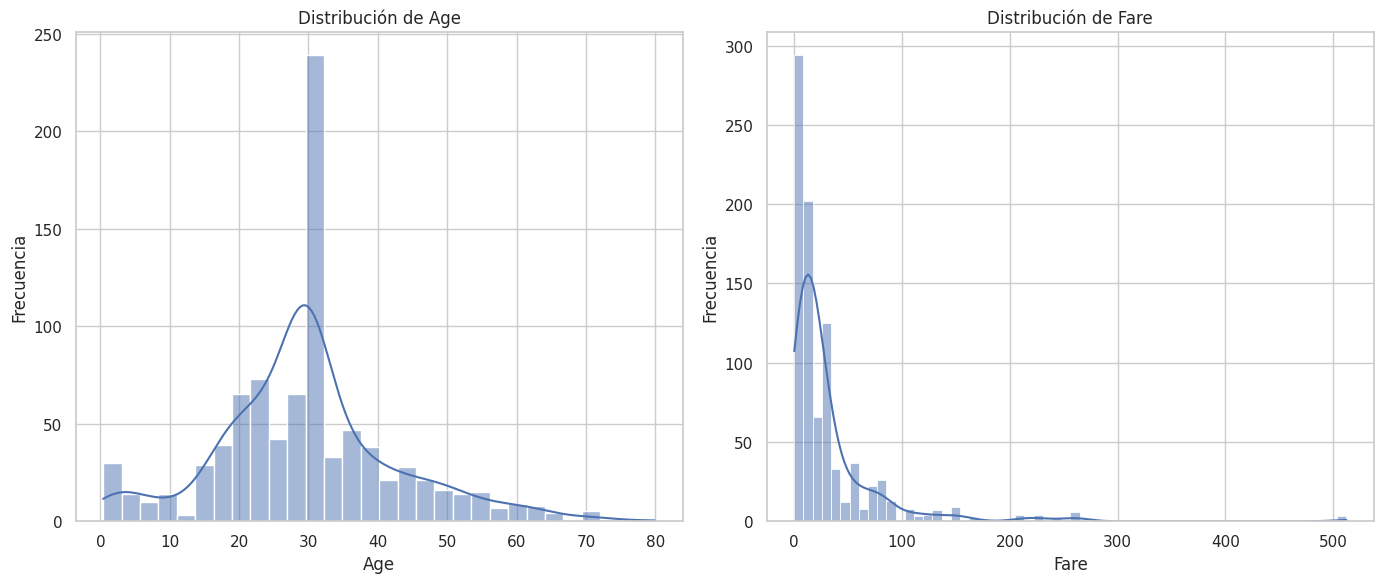

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Normalización con QuantileTransformer

In [5]:
qun_tra_age = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)
qun_tra_fare = QuantileTransformer(output_distribution='normal', n_quantiles=500, random_state=42)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

df[['Age', 'Fare']].describe()

,Age,Fare
count,891.000000,891.000000
mean,-0.000815,-0.037807
std,1.020066,1.189487
min,-5.199338,-5.199338
25%,-0.695130,-0.692839
50%,0.075421,-0.005023
75%,0.663494,0.672914
max,5.199338,5.199338


## Distribución de Age y Fare después de normalizar

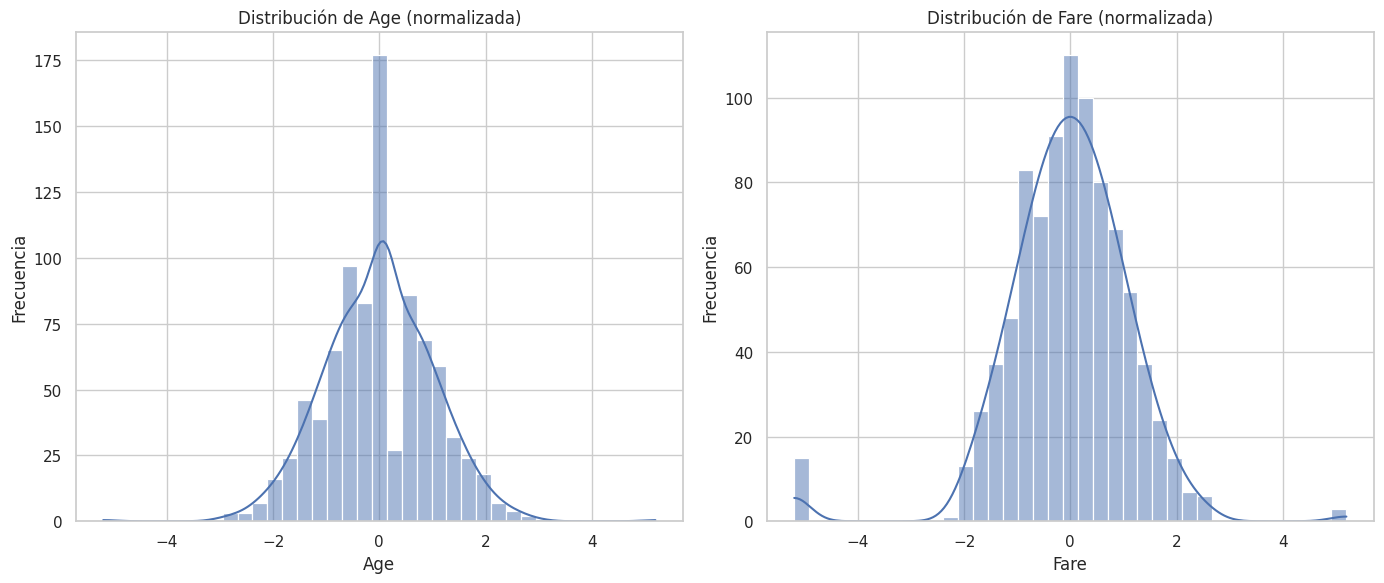

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age (normalizada)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare (normalizada)')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Escalado con MinMaxScaler

In [7]:
mms_pclass = MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,0.654321,0.647587,0.499922,0.065376,0.063599,0.496364,0.768238
std,0.486592,0.418036,0.477990,0.098096,0.137843,0.134343,0.114388,0.395752
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.433152,0.000000,0.000000,0.433372,0.500000
50%,0.000000,1.000000,1.000000,0.507253,0.000000,0.000000,0.499517,1.000000
75%,1.000000,1.000000,1.000000,0.563806,0.125000,0.000000,0.564712,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Muestra final de datos transformados

In [8]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
314,0,0.5,1.0,0.603338,0.125,0.166667,0.542928,1.0
35,0,0.0,1.0,0.598724,0.125,0.000000,0.591629,1.0
3,1,0.0,0.0,0.563806,0.125,0.000000,0.595112,1.0
419,0,1.0,0.0,0.358179,0.000,0.333333,0.529438,1.0
620,0,1.0,1.0,0.467510,0.125,0.000000,0.499517,0.0


## Checkpoint

In [9]:
output_path = './data/titanic_feature_engineering.csv'
df.to_csv(output_path, index=False)
print(f'Dataset guardado en: {output_path}')

Dataset guardado en: ./data/titanic_feature_engineering.csv
